<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW2 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>Desinged by Shaygan Adim</b></p>
</div>

---




*Full Name:* Faraz Doagoye Tehrani

*Student Number:* 402105998

## Homework Overview
In this homework, you will learn to implement, train, and evaluate Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) models on a text classification task using a dataset of IMDB movie reviews, and compare them.

**NOTE : Be sure to answer the analytical questions at the end of the notebook as well.**

In [41]:
# Imports
import nltk
nltk.download('stopwords')
import os
import random
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk import wordpunct_tokenize
from tqdm import tqdm
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from IPython.core.display import display, HTML
from datasets import load_dataset
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score


# Enable tqdm progress bar in pandas
tqdm.pandas()

# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Dataset

In this section, we’ll load the IMDB dataset and preprocess the data to make it suitable for training RNN and LSTM models.

## Load Dataset
Description of Dataset: The IMDB movie reviews dataset consists of reviews along with their labels (positive or negative sentiment). Each review is a sentence or paragraph of text.

Download the Dataset: We will use a Huggingface to download the dataset into our environment.

In [2]:
# Load the IMDb dataset (Hugging Face)
dataset = load_dataset("imdb")

# Make sure 'data' folder exists
os.makedirs('data', exist_ok=True)

# Combine train and test splits into one DataFrame
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Save combined DataFrame to CSV
DATA_PATH = 'data/imdb_reviews.csv'
full_df.to_csv(DATA_PATH, index=False)

print(f"✅ Saved combined IMDb reviews to: {DATA_PATH}")
print(f"Total samples: {len(full_df)}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Saved combined IMDb reviews to: data/imdb_reviews.csv
Total samples: 50000


In [3]:
# Show 5 random samples from the DataFrame
print(full_df.sample(5))

                                                    text  label
46616  This film was not about stereotypes, nor dance...      1
10604  Well this is a typical "straight to the toilet...      0
7206   I was expecting a B-Movie French musical. Afte...      0
38073  First of all, before I start my review, I just...      1
44682  This is a very dark movie, somewhat better tha...      1


## Preprocessing

For our models to work effectively, we need to preprocess the text data by cleaning it and converting words to integer indices for training.Preproces steps
such as Tokenization and Cleaning , Replacing Rare Words , Build Vocabulary , Convert Tokens to Indices and Prepare Data for Training.

**NOTE : Do not alter the structure of this preprocessing code, as it aligns with other parts of the notebook.However, minor adjustments for compatibility with your code are allowed if needed.**

In [4]:
def tokenize(text, stop_words):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    tokens = wordpunct_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

In [5]:
def remove_rare_words(tokens, common_tokens, max_len):
    return [token if token in common_tokens
            else '<UNK>' for token in tokens][-max_len:]

In [6]:
def load_and_preprocess_data(data_path, max_vocab, max_len):
    df = pd.read_csv(data_path)
    stop_words = set(stopwords.words('english'))

    # Clean and tokenize
    df['tokens'] = df['text'].apply(lambda x: tokenize(x, stop_words))

    # Replace rare words with <UNK>
    all_tokens = [token for tokens in df['tokens'] for token in tokens]
    common_tokens = set(list(zip(*Counter(all_tokens).most_common(max_vocab)))[0])
    df['tokens'] = df['tokens'].apply(lambda x: remove_rare_words(x, common_tokens, max_len))

    # Remove sequences with only <UNK>
    df = df[df['tokens'].apply(lambda tokens: any(token != '<UNK>' for token in tokens))]

    # Build vocab
    vocab = sorted(set([token for tokens in df['tokens'] for token in tokens]))
    token2idx = {token: idx for idx, token in enumerate(vocab)}
    token2idx['<PAD>'] = len(token2idx)

    # Index tokens
    df['indexed_tokens'] = df['tokens'].apply(lambda tokens: [token2idx[token] for token in tokens])

    return df['indexed_tokens'].tolist(), df['label'].tolist(), token2idx

In [7]:
# How many of the most common vocab words to keep
# Uncommon words get replaced with unknown token <UNK>
max_vocab = 2500

# How many tokens long each sequence will be cut to
# Shorter sequences will get the padding token <PAD>
max_len = 100

sequences, targets, token2idx = load_and_preprocess_data(DATA_PATH, max_vocab, max_len)


In [8]:
def split_data(sequences, targets, valid_ratio=0.05, test_ratio=0.05):
    total_size = len(sequences)
    test_size = int(total_size * test_ratio)
    valid_size = int(total_size * valid_ratio)
    train_size = total_size - valid_size - test_size

    train_sequences, train_targets = sequences[:train_size], targets[:train_size]
    valid_sequences, valid_targets = sequences[train_size:train_size + valid_size], targets[train_size:train_size + valid_size]
    test_sequences, test_targets = sequences[train_size + valid_size:], targets[train_size + valid_size:]

    return train_sequences, train_targets, valid_sequences, valid_targets, test_sequences, test_targets

In [9]:
sequences, targets = shuffle(
    sequences,
    targets,
    random_state=42
)

train_sequences, train_targets, valid_sequences, valid_targets, test_sequences, test_targets = split_data(sequences, targets)

In [10]:
def collate(batch):
    inputs, targets = zip(*batch)
    inputs_padded = pad_sequences(inputs, padding_val=token2idx['<PAD>'], pad_left=True)
    return torch.LongTensor(inputs_padded), torch.LongTensor(targets)

In [11]:
def pad_sequences(sequences, padding_val=0, pad_left=False):
    """Pad a list of sequences to the same length with a padding_val."""
    sequence_length = max(len(sequence) for sequence in sequences)
    if not pad_left:
        return [sequence + [padding_val] * (sequence_length - len(sequence)) for sequence in sequences]
    return [[padding_val] * (sequence_length - len(sequence)) + sequence for sequence in sequences]

In [12]:
batch_size = 256
train_data = list(zip(train_sequences, train_targets))
valid_data = list(zip(valid_sequences, valid_targets))
test_data = list(zip(test_sequences, test_targets))

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

# RNN section

### RNN with nn.RNN
Implement a basic RNN model using PyTorch's built-in nn.RNN.
Define layers: embedding, RNN, and fully connected.

In [13]:
class RNNClassifier(nn.Module):
    def __init__(self, output_size, hidden_size, vocab_size,
                 device, n_layers=1,
                 embedding_dimension=50):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.device = device
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dimension, padding_idx=token2idx['<PAD>'])

        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        """Define Needed Layers """
        self.rnn = nn.RNN(
        input_size=embedding_dimension,
        hidden_size=hidden_size,
        num_layers=n_layers,
        batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

    def forward(self, inputs):
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        """
        Implements the forward pass: first, embed the input tokens, then pass
        the embeddings through the RNN layer to capture sequential dependencies.
        Finally, use fully connected layers to output class probabilities.
        """
        out = inputs
        batch_size = out.size(0)
        out = self.embedding(out)

        h0 = torch.zeros(self.n_layers, batch_size, self.hidden_size).to(self.device)
        rnn_out, hn = self.rnn(out, h0)

        last_hidden = hn[-1]

        out = self.fc(last_hidden)
        #################################################################################
        #                                   THE END                                     #
        #################################################################################
        return out #probabilities for each class in the output.

### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

**Note**: You are not allowed to use library-built trainer functions in this section; the training loop should be implemented manually.

**Note**: To implement the training loop, you have the option to create a single train_model function that trains a model over multiple epochs, calculates training and validation accuracy, and logs the losses. Once written, this function can be reused for all RNN and LSTM models, allowing you to simply call it with different model instances for training. Reusing the function in this way will ensure that you receive credit for the training section of each subsequent model without needing to write separate loops , with just the correct function call.








In [25]:
model = RNNClassifier(
    output_size=2, 
    hidden_size=512, 
    vocab_size=len(token2idx), 
    device=device,
    embedding_dimension=200
).to(device)

# if torch.cuda.device_count() > 1:
#     print("Using", torch.cuda.device_count(), "GPUs")
#     model = nn.DataParallel(model)
    
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [26]:
def train_model(model, train_loader, valid_loader,criterion, optimizer, device, save_path, epochs=20):

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        train_bar = tqdm(train_loader,
                         desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()

            # Optional but recommended for RNNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            predictions = torch.argmax(outputs, dim=-1)
            correct_preds += (predictions == targets).sum().item()
            total_samples += targets.size(0)

            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_train_loss = running_loss / total_samples
        epoch_train_acc = correct_preds / total_samples

        model.eval()

        valid_loss = 0.0
        correct_valid = 0
        total_valid = 0

        with torch.no_grad():
            for inputs, targets in valid_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, targets)

                valid_loss += loss.item() * inputs.size(0)

                predictions = torch.argmax(outputs, dim=-1)
                correct_valid += (predictions == targets).sum().item()
                total_valid += targets.size(0)

        epoch_valid_loss = valid_loss / total_valid
        epoch_valid_acc = correct_valid / total_valid

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_valid_loss)
        history['val_acc'].append(epoch_valid_acc)

        if epoch_valid_acc > best_val_acc:
            best_val_acc = epoch_valid_acc

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': best_val_acc,
            }, save_path)

            print(f"*** Saved new best model (Val Acc: {best_val_acc:.4f}) ***")

        print(f"Epoch {epoch+1} Summary:")
        print(f"    [Train] Loss: {epoch_train_loss:.4f} , Accuracy: {epoch_train_acc*100:.2f}%")
        print(f"    [Val] Loss: {epoch_valid_loss:.4f} , Accuracy: {epoch_valid_acc*100:.2f}%")

    return history


In [27]:
history = train_model(model, train_loader, valid_loader,criterion, optimizer, device, 'best_model.pt')

Epoch 1/20 [Train]: 100%|██████████| 176/176 [00:04<00:00, 37.39it/s, loss=0.5976]


*** Saved new best model (Val Acc: 0.7183) ***
Epoch 1 Summary:
    [Train] Loss: 0.6366 , Accuracy: 62.02%
    [Val] Loss: 0.5578 , Accuracy: 71.83%


Epoch 2/20 [Train]: 100%|██████████| 176/176 [00:04<00:00, 37.67it/s, loss=0.5799]


*** Saved new best model (Val Acc: 0.7431) ***
Epoch 2 Summary:
    [Train] Loss: 0.5658 , Accuracy: 70.49%
    [Val] Loss: 0.5173 , Accuracy: 74.31%


Epoch 3/20 [Train]: 100%|██████████| 176/176 [00:04<00:00, 37.68it/s, loss=0.5000]


...

Epoch 18 Summary:
    [Train] Loss: 0.3345 , Accuracy: 85.67%
    [Val] Loss: 0.3874 , Accuracy: 83.55%


Epoch 19/20 [Train]: 100%|██████████| 176/176 [00:04<00:00, 36.73it/s, loss=0.4031]


*** Saved new best model (Val Acc: 0.8391) ***
Epoch 19 Summary:
    [Train] Loss: 0.3248 , Accuracy: 86.26%
    [Val] Loss: 0.3962 , Accuracy: 83.91%


Epoch 20/20 [Train]: 100%|██████████| 176/176 [00:04<00:00, 36.82it/s, loss=0.2543]


*** Saved new best model (Val Acc: 0.8395) ***
Epoch 20 Summary:
    [Train] Loss: 0.3202 , Accuracy: 86.33%
    [Val] Loss: 0.3749 , Accuracy: 83.95%


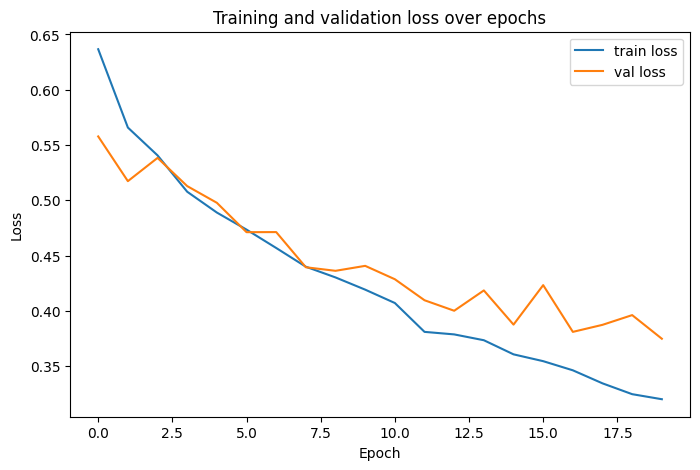

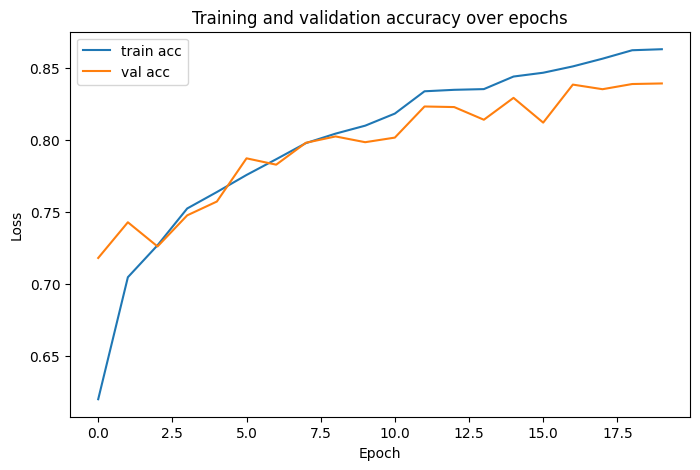

In [28]:
def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='train loss')
    plt.plot(history['val_loss'], label='val loss')
    plt.title('Training and validation loss over epochs')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_acc'], label='train acc')
    plt.plot(history['val_acc'], label='val acc')
    plt.title('Training and validation accuracy over epochs')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history)

### RNN from Scratch
Implement an RNN from scratch by creating a custom RNN cell and a model that stacks these cells over time.

In [18]:
class CustomRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomRNNCell, self).__init__()
        self.hidden_size = hidden_size
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        self.ih = nn.Linear(input_size, hidden_size)
        self.hh = nn.Linear(hidden_size, hidden_size)

        #################################################################################
        #                                   THE END                                     #
        #################################################################################

    def forward(self, input, hidden):
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        input_activation = self.ih(input)
        hidden_activation = self.hh(hidden)
        hidden = torch.tanh(input_activation + hidden_activation)

        #################################################################################
        #                                   THE END                                     #
        #################################################################################
        return hidden


In [19]:
class CustomRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token2idx['<PAD>'])
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        self.rnn_cell = CustomRNNCell(embedding_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

        #################################################################################
        #                                   THE END                                     #
        #################################################################################


    def forward(self, inputs):
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        batch_size, seq_len = inputs.size(0), inputs.size(1)
        embedded = self.embedding(inputs)
        hidden = torch.zeros(batch_size, self.hidden_size, device=inputs.device)
        
        for t in range(seq_len):
            x_t = embedded[:, t, :]
            hidden = self.rnn_cell(x_t, hidden)
            
        out = self.fc(hidden)

        #################################################################################
        #                                   THE END                                     #
        #################################################################################
        return out #probabilities for each class in the output.


### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

In [30]:
costum_model = CustomRNN(output_size=2, 
    hidden_size=512, 
    vocab_size=len(token2idx), 
    embedding_dim=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(costum_model.parameters(), lr=0.0001)

In [31]:
costum_history = train_model(costum_model, train_loader, valid_loader,criterion, optimizer, device, save_path="best_model_costum.pt")

Epoch 1/20 [Train]: 100%|██████████| 176/176 [00:12<00:00, 14.32it/s, loss=0.5706]


*** Saved new best model (Val Acc: 0.6907) ***
Epoch 1 Summary:
    [Train] Loss: 0.6495 , Accuracy: 60.37%
    [Val] Loss: 0.5747 , Accuracy: 69.07%


Epoch 2/20 [Train]: 100%|██████████| 176/176 [00:12<00:00, 14.35it/s, loss=0.5191]


*** Saved new best model (Val Acc: 0.7263) ***
Epoch 2 Summary:
    [Train] Loss: 0.5490 , Accuracy: 71.94%
    [Val] Loss: 0.5428 , Accuracy: 72.63%


Epoch 3/20 [Train]: 100%|██████████| 176/176 [00:12<00:00, 14.37it/s, loss=0.4863]


...

*** Saved new best model (Val Acc: 0.8451) ***
Epoch 18 Summary:
    [Train] Loss: 0.3110 , Accuracy: 86.83%
    [Val] Loss: 0.3611 , Accuracy: 84.51%


Epoch 19/20 [Train]: 100%|██████████| 176/176 [00:12<00:00, 14.22it/s, loss=0.3389]


*** Saved new best model (Val Acc: 0.8455) ***
Epoch 19 Summary:
    [Train] Loss: 0.2965 , Accuracy: 87.31%
    [Val] Loss: 0.3691 , Accuracy: 84.55%


Epoch 20/20 [Train]: 100%|██████████| 176/176 [00:12<00:00, 14.29it/s, loss=0.3198]


Epoch 20 Summary:
    [Train] Loss: 0.2988 , Accuracy: 87.24%
    [Val] Loss: 0.3710 , Accuracy: 83.23%


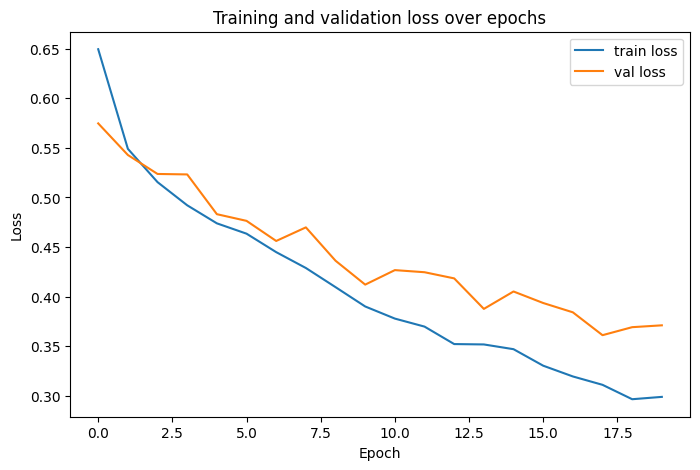

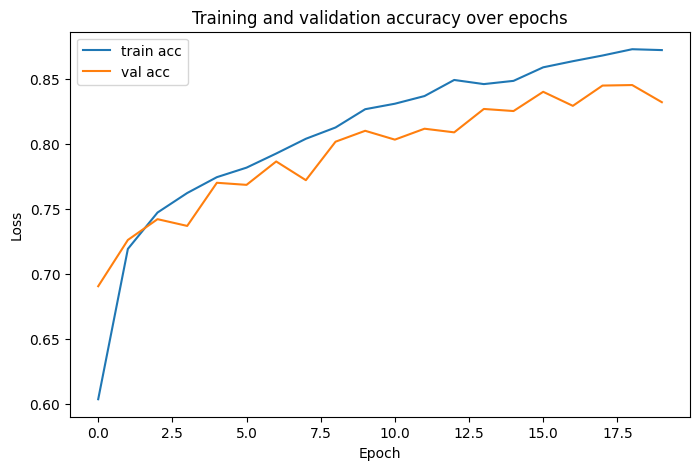

In [32]:
plot_history(costum_history)

### evaluate RNN models on test set
To complete evaluate_on_test, loop through the test data to get predictions, calculate accuracy, and print a classification report for model evaluation. This function can be used to evaluate the performance LSTM models too.

**NOTE : to earn full marks for this section, you must adjust the network's hyperparameters so that each rnn models achieves at least 70% accuracy on the test data. If you achieve less than the required accuracy, consider adjusting your training loop and hyperparameters, such as the hidden state size and learning rate, to improve model performance.**

In [33]:
# Evaluate on test data
def evaluate_on_test(model, test_loader):
    model.eval()
    ############################# TODO #############################
    # TODO: Iterate over the test_loader, obtain model predictions,
    # calculate accuracy, and generate a classification report.
    ################################################################
    y_true_test = []
    y_pred_test = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            predictions = torch.argmax(outputs, dim=-1)
            
            y_true_test.extend(targets.cpu().numpy())
            y_pred_test.extend(predictions.cpu().numpy())
            
    test_accuracy = accuracy_score(y_true_test, y_pred_test)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_true_test, y_pred_test))

In [67]:
model = RNNClassifier(
    output_size=2, 
    hidden_size=512, 
    vocab_size=len(token2idx), 
    device=device,
    embedding_dimension=200
).to(device)
checkpoint = torch.load('best_model.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
model.load_state_dict(model_weights)

evaluate_on_test(model, test_loader)

costum_model = CustomRNN(output_size=2, 
    hidden_size=512, 
    vocab_size=len(token2idx), 
    embedding_dim=200).to(device)
checkpoint = torch.load('best_model_costum.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
costum_model.load_state_dict(model_weights)

evaluate_on_test(costum_model, test_loader)

Test Accuracy: 82.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1256
           1       0.81      0.86      0.83      1243

    accuracy                           0.83      2499
   macro avg       0.83      0.83      0.83      2499
weighted avg       0.83      0.83      0.83      2499

Test Accuracy: 83.63%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1256
           1       0.86      0.80      0.83      1243

    accuracy                           0.84      2499
   macro avg       0.84      0.84      0.84      2499
weighted avg       0.84      0.84      0.84      2499



# LSTM section

### LSTM with nn.LSTM
Define an LSTM model using PyTorch's built-in nn.LSTM.

In [43]:
class LSTMClassifier(nn.Module):
    def __init__(self, output_size, hidden_size, vocab_size,
                 device, bidirectional=False, n_layers=1,
                 embedding_dimension=50):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.device = device

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dimension, padding_idx = token2idx['<PAD>'])

        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        self.lstm = nn.LSTM(
            input_size=embedding_dimension,
            hidden_size=hidden_size,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True
        )
        
        self.num_directions = 2 if bidirectional else 1
        
        self.fc = nn.Linear(hidden_size * self.num_directions, output_size)
            
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

    def forward(self, inputs):
        # Initialize hidden state and cell state with zeros
        hidden = torch.zeros(self.n_layers, inputs.size(0), self.hidden_size).to(inputs.device)
        cell_state = torch.zeros(self.n_layers, inputs.size(0), self.hidden_size).to(inputs.device)

        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        embeds = self.embedding(inputs)
        
        lstm_out, (hidden, cell_state) = self.lstm(embeds, (hidden, cell_state))
        
        if self.lstm.bidirectional:
            final_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            final_hidden = hidden[-1,:,:]
            
        out = self.fc(final_hidden)
        
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

        return out  # probabilities for each class in the output.

### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

**Note**: You are not allowed to use library-built trainer functions in this section; the training loop should be implemented manually.

**Note**: To implement the training loop, you have the option to create a single train_model function that trains a model over multiple epochs, calculates training and validation accuracy, and logs the losses. Once written, this function can be reused for all RNN and LSTM models, allowing you to simply call it with different model instances for training. Reusing the function in this way will ensure that you receive credit for the training section of each subsequent model without needing to write separate loops , with just the correct function call.

In [51]:
lstm_model = LSTMClassifier(output_size=2, hidden_size=512, vocab_size=len(token2idx), 
                    device=device,n_layers=1,
                    embedding_dimension=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.0001)

In [52]:
lstm_history = train_model(lstm_model, train_loader, valid_loader,criterion, optimizer, device, save_path="best_model_lstm.pt")

Epoch 1/20 [Train]: 100%|██████████| 176/176 [00:13<00:00, 13.21it/s, loss=0.4977]


*** Saved new best model (Val Acc: 0.7615) ***
Epoch 1 Summary:
    [Train] Loss: 0.6139 , Accuracy: 65.37%
    [Val] Loss: 0.4996 , Accuracy: 76.15%


Epoch 2/20 [Train]: 100%|██████████| 176/176 [00:13<00:00, 13.10it/s, loss=0.4392]


*** Saved new best model (Val Acc: 0.8011) ***
Epoch 2 Summary:
    [Train] Loss: 0.4754 , Accuracy: 77.51%
    [Val] Loss: 0.4456 , Accuracy: 80.11%


Epoch 3/20 [Train]: 100%|██████████| 176/176 [00:13<00:00, 12.96it/s, loss=0.4028]


...

Epoch 18 Summary:
    [Train] Loss: 0.2177 , Accuracy: 91.12%
    [Val] Loss: 0.3769 , Accuracy: 86.11%


Epoch 19/20 [Train]: 100%|██████████| 176/176 [00:14<00:00, 12.37it/s, loss=0.1587]


Epoch 19 Summary:
    [Train] Loss: 0.2119 , Accuracy: 91.48%
    [Val] Loss: 0.3207 , Accuracy: 87.60%


Epoch 20/20 [Train]: 100%|██████████| 176/176 [00:14<00:00, 12.37it/s, loss=0.2118]


Epoch 20 Summary:
    [Train] Loss: 0.1988 , Accuracy: 91.94%
    [Val] Loss: 0.3248 , Accuracy: 87.31%


In [ ]:
plot_history(lstm_history)

### Custom LSTM from Scratch
Implement an LSTM from scratch by defining a LSTM cell and a model that combines these cells over the sequence.

In [55]:
class CustomLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        #(Forget, Input, Candidate, Output gates)
        self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

    def forward(self, input, hidden, cell_state):
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        combined = torch.cat((input, hidden), dim=1)
        gate_outputs = self.gates(combined)
        f_gate, i_gate, c_tilde, o_gate = torch.chunk(gate_outputs, chunks=4, dim=1)
        f_t = torch.sigmoid(f_gate)       
        i_t = torch.sigmoid(i_gate)       
        c_tilde_t = torch.tanh(c_tilde)   
        o_t = torch.sigmoid(o_gate)      
        
        cell_state = (f_t * cell_state) + (i_t * c_tilde_t)
        
        hidden = o_t * torch.tanh(cell_state)

        #################################################################################
        #                                   THE END                                     #
        #################################################################################

        return hidden, cell_state # New hidden state , New cell state


In [56]:
class CustomLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(CustomLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token2idx['<PAD>'])
        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        self.lstm_cell = CustomLSTMCell(embedding_dim, hidden_size)
        
        self.fc = nn.Linear(hidden_size, output_size)
        
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

    def forward(self, inputs):
        # Initialize hidden state and cell state with zeros
        hidden = torch.zeros(inputs.size(0), self.hidden_size).to(inputs.device)
        cell_state = torch.zeros(inputs.size(0), self.hidden_size).to(inputs.device)

        ###################################### TODO #####################################
        #                          COMPLETE THE FOLLOWING SECTION                       #
        #################################################################################
        embeds = self.embedding(inputs)
        
        seq_len = embeds.size(1)
        for t in range(seq_len):
            x_t = embeds[:, t, :]
            
            hidden, cell_state = self.lstm_cell(x_t, hidden, cell_state)
            
        out = self.fc(hidden)
        #################################################################################
        #                                   THE END                                     #
        #################################################################################

        return out  # probabilities for each class in the output.


### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

In [61]:
costum_lstm_model = CustomLSTM(output_size=2, hidden_size=512, vocab_size=len(token2idx),
                    embedding_dim=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(costum_lstm_model.parameters(), lr=0.0001)

In [62]:
costum_lstm_history = train_model(costum_lstm_model, train_loader, valid_loader,criterion, optimizer, device, save_path="best_model_costum_lstm.pt")

Epoch 1/20 [Train]: 100%|██████████| 176/176 [00:20<00:00,  8.58it/s, loss=0.5054]


*** Saved new best model (Val Acc: 0.7507) ***
Epoch 1 Summary:
    [Train] Loss: 0.6072 , Accuracy: 65.31%
    [Val] Loss: 0.4967 , Accuracy: 75.07%


Epoch 2/20 [Train]: 100%|██████████| 176/176 [00:20<00:00,  8.57it/s, loss=0.5083]


*** Saved new best model (Val Acc: 0.7723) ***
Epoch 2 Summary:
    [Train] Loss: 0.4672 , Accuracy: 77.69%
    [Val] Loss: 0.4956 , Accuracy: 77.23%


Epoch 3/20 [Train]: 100%|██████████| 176/176 [00:20<00:00,  8.48it/s, loss=0.3917]


...

Epoch 18 Summary:
    [Train] Loss: 0.2268 , Accuracy: 90.86%
    [Val] Loss: 0.3344 , Accuracy: 86.15%


Epoch 19/20 [Train]: 100%|██████████| 176/176 [00:21<00:00,  8.16it/s, loss=0.2063]


Epoch 19 Summary:
    [Train] Loss: 0.2189 , Accuracy: 91.04%
    [Val] Loss: 0.3466 , Accuracy: 86.31%


Epoch 20/20 [Train]: 100%|██████████| 176/176 [00:21<00:00,  8.16it/s, loss=0.2347]


Epoch 20 Summary:
    [Train] Loss: 0.2115 , Accuracy: 91.46%
    [Val] Loss: 0.3588 , Accuracy: 86.07%


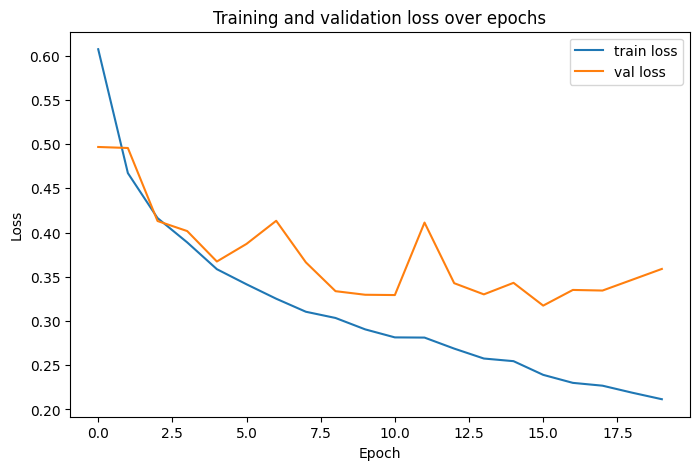

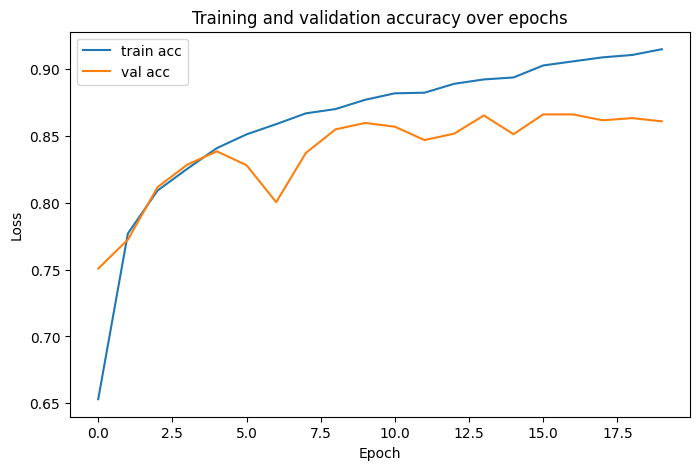

In [63]:
plot_history(costum_lstm_history)

### evaluate LSTM models on test set
To complete evaluate_on_test, loop through the test data to get predictions, calculate accuracy, and print a classification report for model evaluation.
you can use the `evaluate_on_test` function implemented in the previous section. Alternatively, you may write a new function to conduct this evaluation.ensure report the "classification_report" of both LSTM models.

**NOTE : to earn full marks for this section, you must adjust the network's hyperparameters so that each lstm models achieves at least 80% accuracy on the test data. If you achieve less than the required accuracy, consider adjusting your training loop and hyperparameters, such as the hidden state size and learning rate, to improve model performance.**

In [65]:
lstm_model = LSTMClassifier(output_size=2, hidden_size=512, vocab_size=len(token2idx), 
                    device=device,n_layers=1,
                    embedding_dimension=200).to(device)
checkpoint = torch.load('best_model_lstm.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
lstm_model.load_state_dict(model_weights)

evaluate_on_test(lstm_model, test_loader)

costum_lstm_model = CustomLSTM(output_size=2, hidden_size=512, vocab_size=len(token2idx),
                    embedding_dim=200).to(device)
checkpoint = torch.load('best_model_costum_lstm.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
costum_lstm_model.load_state_dict(model_weights)

evaluate_on_test(costum_model, test_loader)


Test Accuracy: 86.03%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1256
           1       0.85      0.88      0.86      1243

    accuracy                           0.86      2499
   macro avg       0.86      0.86      0.86      2499
weighted avg       0.86      0.86      0.86      2499

Test Accuracy: 83.63%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1256
           1       0.86      0.80      0.83      1243

    accuracy                           0.84      2499
   macro avg       0.84      0.84      0.84      2499
weighted avg       0.84      0.84      0.84      2499



# Testing RNN and LSTM Models on a New Review

In [68]:
# Example review
review = "It is no wonder that the film has such a high rating, it is quite literally breathtaking. What can I say that hasn't said before? Not much, it's the story, the acting, the premise, but most of all, this movie is about how it makes you feel. Sometimes you watch a film, and can't remember it days later, this film loves with you, once you've seen it, you don't forget."


## Preprocess the test Review
To prepare the review for the model, we need to follow similar preprocessing steps as we did for the dataset:

Remove special characters and convert the text to lowercase.
Tokenize the text into individual words.
Remove stopwords to focus only on meaningful words.
Convert tokens to indices based on the token2idx dictionary created earlier.
Pad or truncate the sequence to a length of max_len .


In [70]:
import torch
import re
from nltk import wordpunct_tokenize
from nltk.corpus import stopwords


# Preprocessing function
def preprocess_text(text, stop_words, token2idx, max_len):

    ########################### TODO ###########################
    # Step 1: Clean and lowercase the input text
    ################################################################

    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)

    ########################### TODO ###########################
    # Step 2: Tokenize the text into words
    # - Use wordpunct_tokenize to split the cleaned text into individual word tokens.
    ############################################################

    tokens = wordpunct_tokenize(text)
    ########################### TODO ###########################
    # Step 3: Remove stopwords from the token list
    ############################################################

    tokens = [token for token in tokens if token not in stop_words]
    ########################### TODO ###########################
    # Step 4: Convert tokens to indices based on the token2idx dictionary
    # - For each token in the list, get the corresponding index from the token2idx dictionary.
    # - If a token is not found in token2idx, replace it with the index of '<UNK>'.
    ################################################################

    tokens_idx = [token2idx.get(token, token2idx['<UNK>']) for token in tokens]
    ########################### TODO ###########################
    # Step 5: Pad or truncate the tokens_idx list to the desired max_len
    ############################################################

    if len(tokens_idx) > max_len:
        tokens_idx = tokens_idx[:max_len]
    else:
        padding_count = max_len - len(tokens_idx)
        tokens_idx = tokens_idx + [token2idx['<PAD>']] * padding_count

    ########################### End of TODOs ###########################

    return tokens_idx  # Return the processed list of indices

# Get stopwords
stop_words = set(stopwords.words('english'))

########################### TODO ###########################
# Preprocess the review
review_indices = preprocess_text(review, stop_words, token2idx, max_len)
############################################################

# Convert the indices to a tensor and move it to the device (GPU or CPU)
input_tensor = torch.LongTensor([review_indices]).to(device)

## Make Predictions
Now that we have preprocessed the review, use both the RNN and LSTM models to make predictions on the sentiment of the review.

Set the model to evaluation mode to prevent updates during inference.
Predict the sentiment class by passing the input_tensor to the model.
Interpret the prediction as either "Positive" or "Negative" based on the model's output.

In [72]:
def predict_sentiment(model, input_tensor, model_name="Model"):
    model.eval()  # Set the model to evaluation mode
    ############################# TODO #############################
    # TODO: Perform a forward pass with the model on the input_tensor,
    # get the predicted class label, and map it to "Positive" or "Negative".
    ################################################################
    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_idx = torch.argmax(outputs, dim=1).item()
        class_label = "Positive" if predicted_idx == 1 else "Negative"

    print(f"The predicted class for the review by {model_name} is: {class_label}")

In [74]:
# Make predictions using with "predict_sentiment" function for each of four models above
predict_sentiment(model, input_tensor, model_name="RNN")
predict_sentiment(costum_model, input_tensor, model_name="RNN Costum")

predict_sentiment(lstm_model, input_tensor, model_name="LSTM")
predict_sentiment(costum_lstm_model, input_tensor, model_name="LSTM Costum")


The predicted class for the review by RNN is: Positive
The predicted class for the review by RNN Costum is: Positive
The predicted class for the review by LSTM is: Positive
The predicted class for the review by LSTM Costum is: Positive


# Questions

[1] - Based on your observations, what do you think caused the difference in performance between the RNN and LSTM models (on test set)? Analyze this difference using the results from the notebook, and discuss where a simple RNN might perform better.

An RNN struggles with longer sequences because its gradients vanish during training, causing it to quickly forget information from the beginning of a review. An LSTM fixes this issue by using a dedicated cell state and gating system that safely carries early context across many time steps. A simple RNN would only perform better on very short sequences, tasks where only the most recent words matter, or in scenarios where you have strictly limited computing power and data.

[2] - If we increase max_len in the preprocessing step to 300, what changes in models (rnn & lstm ) performance would you expect, and why? Please *explain* and discuss the impact this may have on the learning process and the final results.


The LSTM will likely maintain or improve its performance because it can successfully capture the extra context from longer reviews. However, the RNN will suffer because the added length makes the vanishing gradient problem even worse.